# Seminar 1 AAX | Linear Regression for Wi‑Fi Throughput Prediction

**Antoine Metz** `335801`  
**Corentin Le Bris** `335776`

This notebook studies the Seminar 1 Wi‑Fi dataset and focuses on **throughput prediction** with linear regression.

The objective is not only to fit a baseline model, but also to answer three methodological questions:

1. Are some input variables effectively **discrete / categorical-like** rather than continuous?
2. Are some explanatory variables **redundant**, creating **multicollinearity**?
3. Does a more careful specification of the linear model improve interpretability and predictive performance?

## 1. Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 2. Load the dataset

The file is read from a text file using whitespace separation.  
We then assign the 16 column names given in the seminar slides.

In [2]:
column_names = [
    "num_stas",
    "load",
    "size_x",
    "size_y",
    "area",
    "cw",
    "channel_width",
    "packet_size",
    "max_rssi",
    "avg_rssi",
    "min_rssi",
    "failure_prob",
    "throughput",
    "delay",
    "total_airtime",
    "prop_airtime"
]

df = pd.read_csv(
    "datasetsem1.txt",
    header=None,
    sep=r"\s+",
    engine="python"
)

df.columns = column_names

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (100000, 16)


,num_stas,load,size_x,size_y,area,cw,channel_width,packet_size,max_rssi,avg_rssi,min_rssi,failure_prob,throughput,delay,total_airtime,prop_airtime
0,40.0,60000000.0,22.0,39.0,858.0,63.0,80.0,4000.0,-42.928330,-63.163012,-74.965338,0.415189,7.208644e+06,1.229466e+07,1.084041,0.875490
1,35.0,52500000.0,20.0,33.0,660.0,31.0,40.0,10000.0,-47.815800,-63.298410,-72.847989,0.485311,1.545116e+07,1.275042e+07,1.111263,0.873785
2,16.0,12000000.0,34.0,14.0,476.0,255.0,40.0,4000.0,-46.138494,-60.076333,-70.044800,0.099413,6.743660e+06,2.251690e+06,0.880036,0.849701
3,37.0,18500000.0,35.0,7.0,245.0,31.0,80.0,10000.0,-42.708813,-60.141393,-72.029643,0.493704,1.675025e+07,1.211374e+07,1.126341,0.860103
4,18.0,4500000.0,36.0,35.0,1260.0,127.0,160.0,8000.0,-45.492991,-63.780783,-76.225550,0.011664,4.500000e+06,1.446000e-03,0.276770,0.275687


## 3. Data quality checks

We first verify basic properties of the dataset: types, missing values, duplicates, and simple descriptive statistics.

In [3]:
print("Data types:")
display(df.dtypes.to_frame(name="dtype").T)

print("Missing values per column:")
display(df.isnull().sum().to_frame(name="missing_values").T)

print("Number of duplicated rows:", int(df.duplicated().sum()))

stats_df = df.describe().T
stats_df["variance"] = df.var(numeric_only=True)
display(stats_df)

Data types:


,num_stas,load,size_x,size_y,area,cw,channel_width,packet_size,max_rssi,avg_rssi,min_rssi,failure_prob,throughput,delay,total_airtime,prop_airtime
dtype,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64


Missing values per column:


,num_stas,load,size_x,size_y,area,cw,channel_width,packet_size,max_rssi,avg_rssi,min_rssi,failure_prob,throughput,delay,total_airtime,prop_airtime
missing_values,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Number of duplicated rows: 0


,count,mean,std,min,25%,50%,75%,max,variance
num_stas,100000.0,2.144617e+01,1.155437e+01,2.000000,1.100000e+01,2.100000e+01,3.100000e+01,4.100000e+01,1.335034e+02
load,100000.0,2.140292e+07,1.852042e+07,500000.000000,7.250000e+06,1.600000e+07,3.000000e+07,8.200000e+07,3.430060e+14
size_x,100000.0,2.056294e+01,1.154521e+01,1.000000,1.100000e+01,2.100000e+01,3.100000e+01,4.000000e+01,1.332918e+02
size_y,100000.0,2.047964e+01,1.154063e+01,1.000000,1.100000e+01,2.000000e+01,3.000000e+01,4.000000e+01,1.331860e+02
area,100000.0,4.212704e+02,3.603443e+02,1.000000,1.200000e+02,3.200000e+02,6.400000e+02,1.600000e+03,1.298480e+05
cw,100000.0,2.270439e+02,3.233509e+02,3.000000,1.500000e+01,6.300000e+01,2.550000e+02,1.023000e+03,1.045558e+05
channel_width,100000.0,7.510600e+01,5.370428e+01,20.000000,2.000000e+01,8.000000e+01,1.600000e+02,1.600000e+02,2.884150e+03
packet_size,100000.0,7.997580e+03,2.825533e+03,4000.000000,6.000000e+03,8.000000e+03,1.000000e+04,1.200000e+04,7.983634e+06
max_rssi,100000.0,-4.591117e+01,5.400265e+00,-81.405165,-4.813148e+01,-4.411106e+01,-4.188882e+01,-4.086359e+01,2.916287e+01
avg_rssi,100000.0,-5.757743e+01,6.108548e+00,-81.405165,-6.198500e+01,-5.816321e+01,-5.358953e+01,-4.086596e+01,3.731435e+01


### Comment

The dataset is numerically clean: there are no missing values and no duplicated rows.  
However, this does **not** mean that all variables should automatically be treated in the same way in the model.  
In particular, some variables appear to take only a small set of admissible values, which suggests a **discrete / categorical-like** structure.

## 4. Distribution of the variables

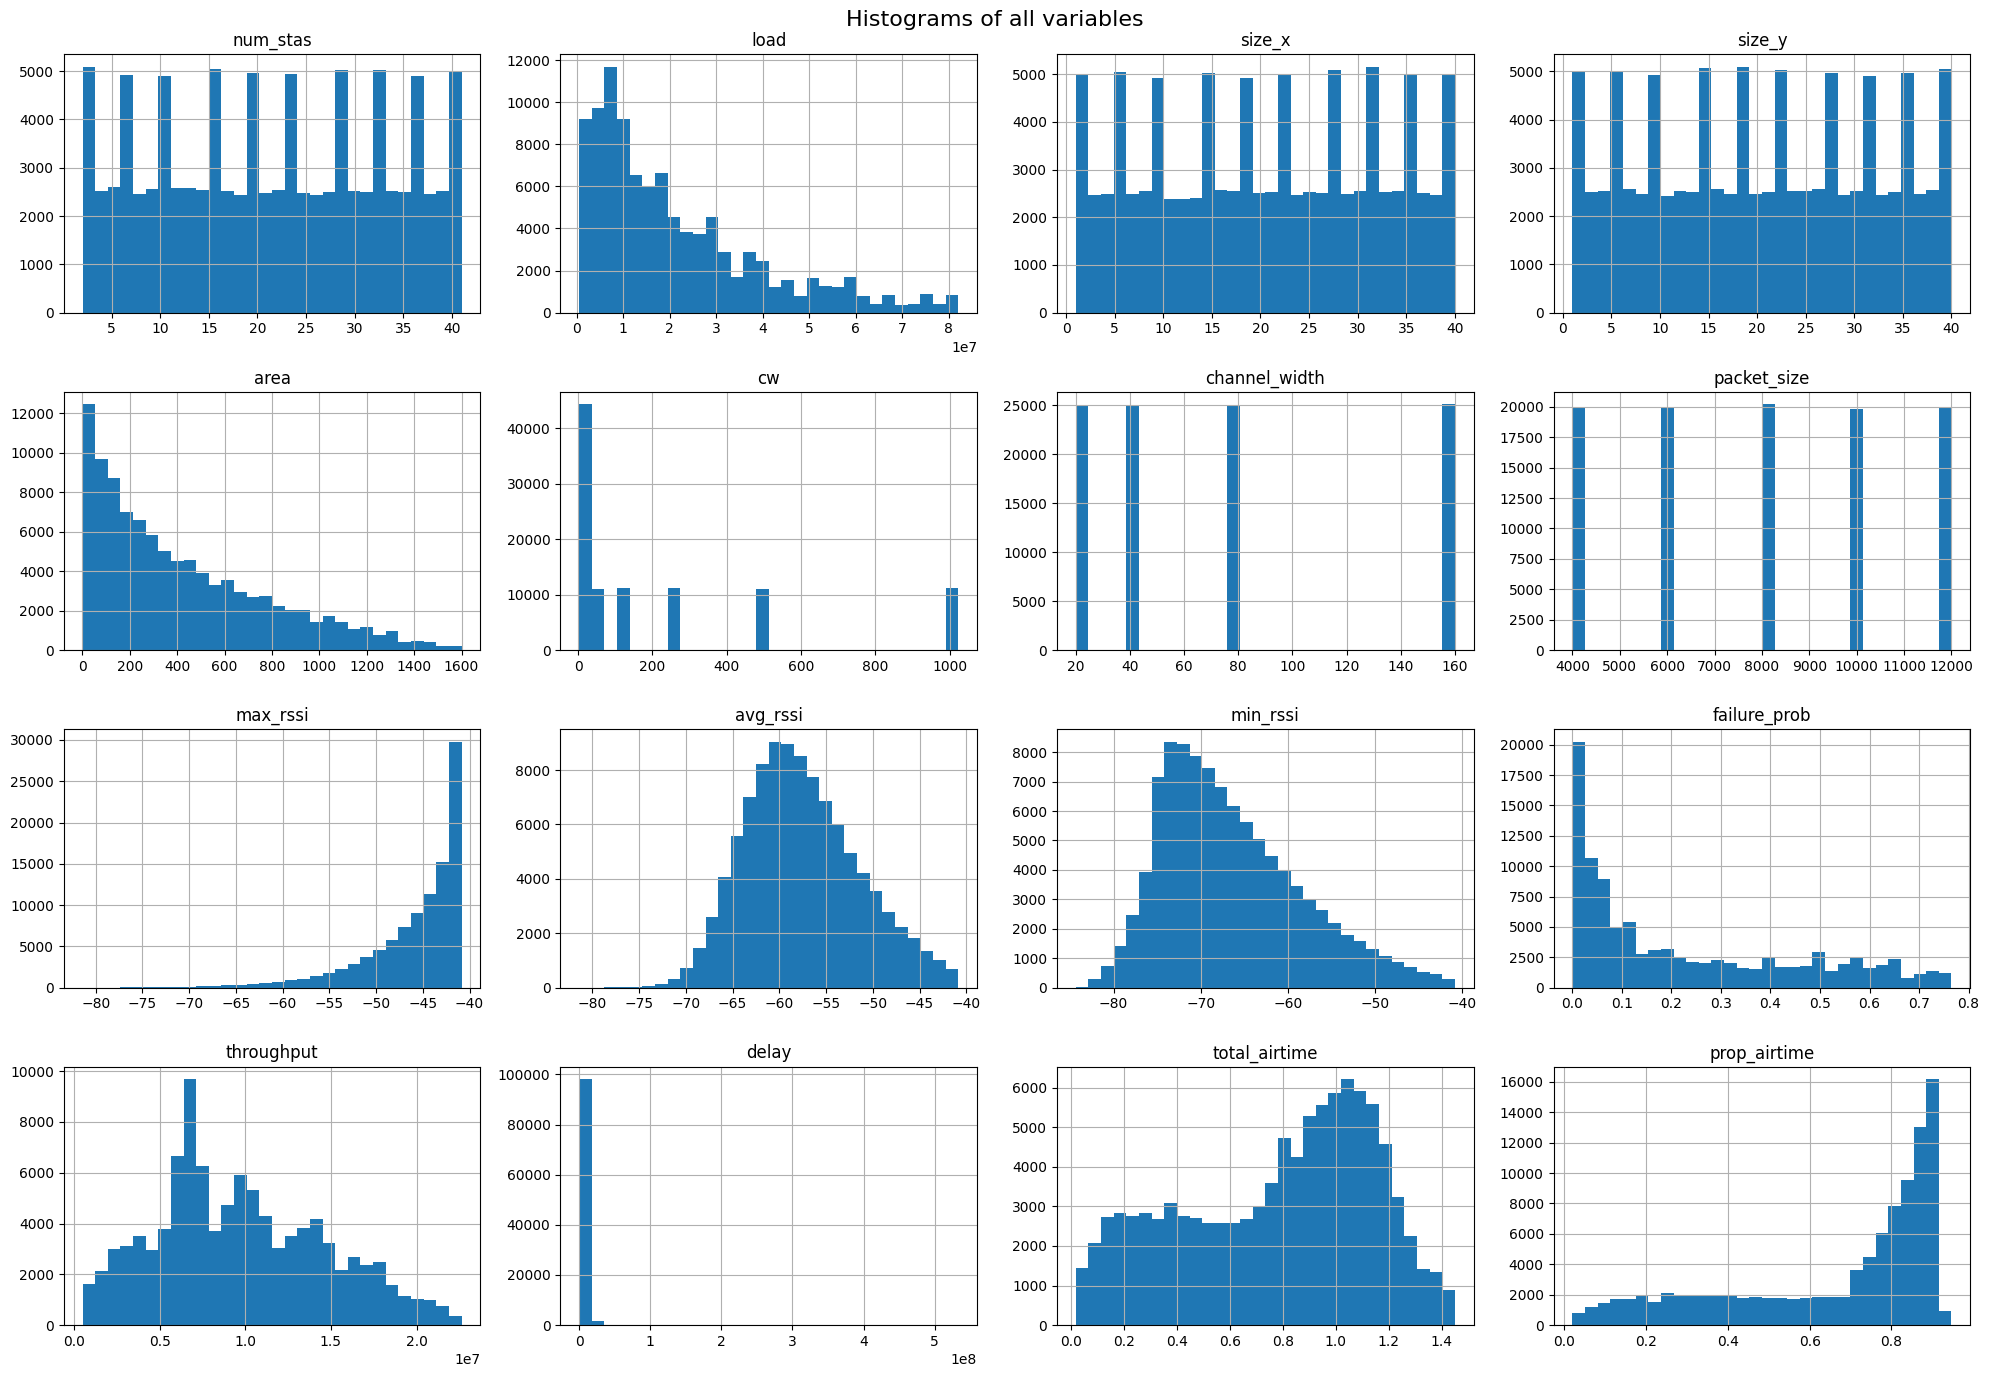

In [4]:
df.hist(figsize=(20, 14), bins=30)
plt.suptitle("Histograms of all variables", fontsize=16)
plt.tight_layout()
plt.show()

## 5. Which variables look discrete?

A professor's remark is especially relevant here: variables such as `cw`, `channel_width`, and `packet_size` do not behave like continuous measurements.  
They take a **small number of predefined values**, so it is reasonable to test them both:

- as numerical variables,
- and as **categorical-like variables** using one-hot encoding.

In [5]:
suspected_discrete = ["cw", "channel_width", "packet_size"]

for col in suspected_discrete:
    uniques = np.sort(df[col].unique())
    print(f"{col}: {len(uniques)} unique values")
    print(uniques)
    print("-" * 60)

cw: 9 unique values
[   3.    7.   15.   31.   63.  127.  255.  511. 1023.]
------------------------------------------------------------
channel_width: 4 unique values
[ 20.  40.  80. 160.]
------------------------------------------------------------
packet_size: 5 unique values
[ 4000.  6000.  8000. 10000. 12000.]
------------------------------------------------------------


### Comment

This output shows that `cw`, `channel_width`, and `packet_size` only take a few possible values.

- `cw` has 9 values,
- `channel_width` has 4 values,
- `packet_size` has 5 values.

So these variables do not really behave like continuous variables.  
It makes sense to test two approaches: keeping them as numerical values, or encoding them as categorical-like variables with one-hot encoding.

## 6. Global correlation matrix

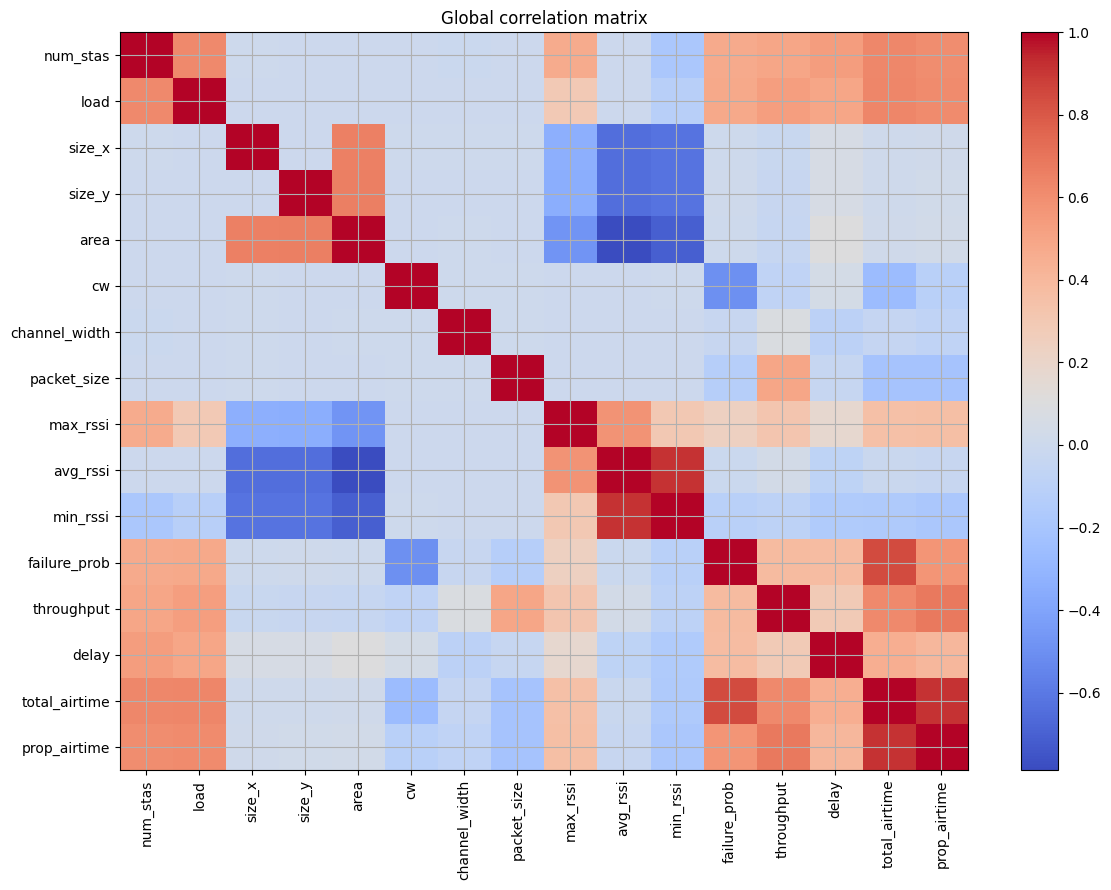

In [6]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))
plt.imshow(corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Global correlation matrix")
plt.tight_layout()
plt.show()

## 7. Multicollinearity analysis between input features

At this stage, the goal is **not** to correlate the features with the target, but to detect **dependencies between explanatory variables**.

This matters because multicollinearity can:
- make coefficients unstable,
- inflate standard errors,
- weaken interpretability,
- and create misleading significance tests.

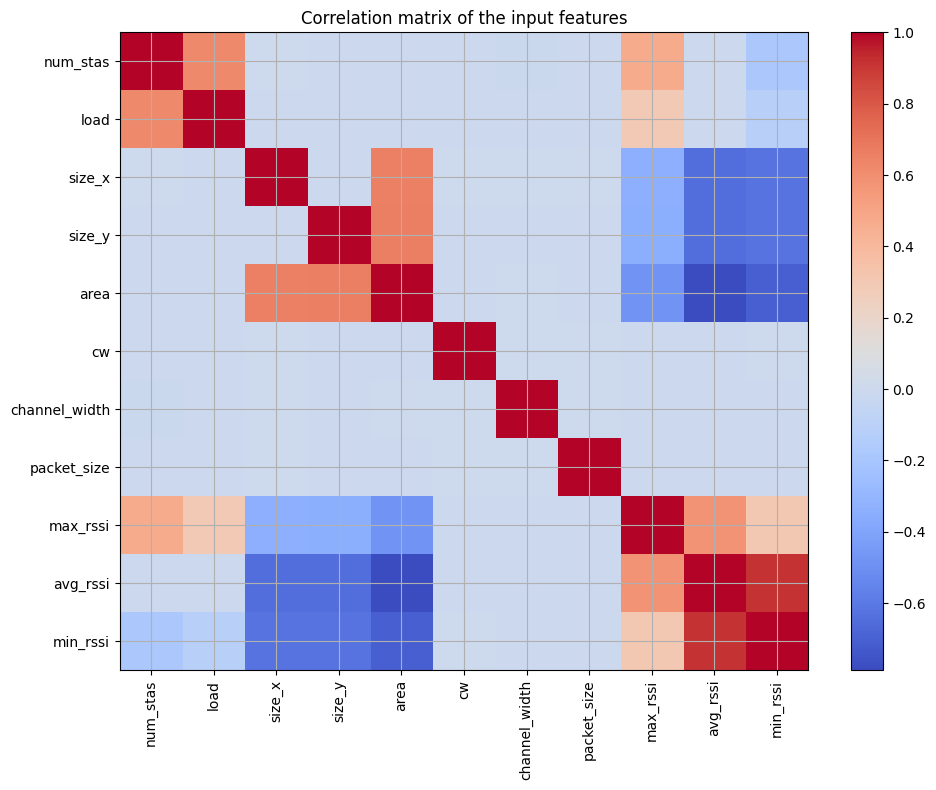

In [7]:
all_features = [
    "num_stas", "load", "size_x", "size_y", "area", "cw",
    "channel_width", "packet_size", "max_rssi", "avg_rssi", "min_rssi"
]

corr_features = df[all_features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_features, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(all_features)), all_features, rotation=90)
plt.yticks(range(len(all_features)), all_features)
plt.title("Correlation matrix of the input features")
plt.tight_layout()
plt.show()

### Strongly correlated feature pairs

In [8]:
corr_abs = df[all_features].corr().abs()
threshold = 0.80

strong_pairs = []
for i in range(len(corr_abs.columns)):
    for j in range(i + 1, len(corr_abs.columns)):
        value = corr_abs.iloc[i, j]
        if value >= threshold:
            strong_pairs.append({
                "feature_1": corr_abs.columns[i],
                "feature_2": corr_abs.columns[j],
                "abs_correlation": value
            })

strong_pairs_df = pd.DataFrame(strong_pairs).sort_values(by="abs_correlation", ascending=False)
if len(strong_pairs_df) == 0:
    display(pd.DataFrame({"message": ["No pair above threshold"]}))
else:
    display(strong_pairs_df)

,feature_1,feature_2,abs_correlation
0,avg_rssi,min_rssi,0.911526


### Comment

With the 0.80 threshold, the only very strong pairwise correlation is between `avg_rssi` and `min_rssi` (about 0.91).

This means these two variables bring very similar information.  
For the other variables, the pairwise correlations are not above the threshold, but that does not fully rule out multicollinearity.  
That is why the VIF analysis is still necessary.

## 8. Variance Inflation Factor (VIF)

The VIF is the standard diagnostic for multicollinearity.  
Rough interpretation:

- **VIF ≈ 1**: no multicollinearity issue,
- **VIF > 5**: moderate concern,
- **VIF > 10**: strong multicollinearity.

In [9]:
def compute_vif(dataframe, features):
    X_vif = sm.add_constant(dataframe[features])
    vif_df = pd.DataFrame({
        "variable": X_vif.columns,
        "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
    })
    return vif_df.sort_values(by="VIF", ascending=False)

vif_all = compute_vif(df, all_features)
display(vif_all)

,variable,VIF
0,const,413.438115
10,avg_rssi,17.165973
4,size_y,16.435732
3,size_x,16.411121
11,min_rssi,16.175584
5,area,12.912684
9,max_rssi,3.375065
1,num_stas,2.278665
2,load,1.629755
7,channel_width,1.000139


### Reduced feature set proposal

To reduce multicollinearity, we define a more conservative specification:

- remove `area` because it is redundant with `size_x` and `size_y`;
- keep only `avg_rssi` among the three RSSI indicators;
- keep `cw`, `channel_width`, and `packet_size`, but later test them both as numeric and as categorical-like variables.

In [10]:
reduced_features = [
    "num_stas", "load", "size_x", "size_y",
    "cw", "channel_width", "packet_size", "avg_rssi"
]

vif_reduced = compute_vif(df, reduced_features)
display(vif_reduced)

,variable,VIF
0,const,319.708284
8,avg_rssi,5.863667
3,size_x,3.432765
4,size_y,3.425635
1,num_stas,1.629733
2,load,1.629677
6,channel_width,1.000092
5,cw,1.000082
7,packet_size,1.000063


The VIF values confirm that the full model has real multicollinearity issues.

The main problematic variables are:
- `avg_rssi`,
- `size_x`,
- `size_y`,
- `min_rssi`,
- `area`.

All of them have VIF values above 10, which is usually considered too high.

This makes sense:
- `area` is linked to `size_x` and `size_y`,
- and the RSSI variables clearly overlap.

On the contrary, `cw`, `channel_width`, and `packet_size` have VIF values close to 1, so they are not part of the collinearity problem.

## 9. Train / test split

The target variable is **throughput**.  
We keep the same train/test split for all models in order to make the comparison fair.

In [11]:
target = "throughput"

X_full = df[all_features].copy()
X_reduced = df[reduced_features].copy()
y = df[target].copy()

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_full, y, test_size=0.2, random_state=42
)

X_train_reduced = X_train_full[reduced_features].copy()
X_test_reduced = X_test_full[reduced_features].copy()

print("Train shape (full):", X_train_full.shape)
print("Test shape  (full):", X_test_full.shape)
print("Train shape (reduced):", X_train_reduced.shape)
print("Test shape  (reduced):", X_test_reduced.shape)

Train shape (full): (80000, 11)
Test shape  (full): (20000, 11)
Train shape (reduced): (80000, 8)
Test shape  (reduced): (20000, 8)


## 10. Utility functions

In [12]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return mae, mse, rmse, r2

def evaluate_model(y_train, y_pred_train, y_test, y_pred_test, model_name):
    train_mae, train_mse, train_rmse, train_r2 = regression_metrics(y_train, y_pred_train)
    test_mae, test_mse, test_rmse, test_r2 = regression_metrics(y_test, y_pred_test)

    return {
        "model": model_name,
        "train_MAE": train_mae,
        "train_MSE": train_mse,
        "train_RMSE": train_rmse,
        "train_R2": train_r2,
        "test_MAE": test_mae,
        "test_MSE": test_mse,
        "test_RMSE": test_rmse,
        "test_R2": test_r2
    }

## 11. Model A — Full linear regression (all variables treated as numerical)

This is the simplest baseline and reproduces the standard multivariable linear regression setup.

In [13]:
scaler_full = StandardScaler()
X_train_full_scaled = scaler_full.fit_transform(X_train_full)
X_test_full_scaled = scaler_full.transform(X_test_full)

model_full = LinearRegression()
model_full.fit(X_train_full_scaled, y_train)

y_pred_train_full = model_full.predict(X_train_full_scaled)
y_pred_test_full = model_full.predict(X_test_full_scaled)

results = []
results.append(evaluate_model(y_train, y_pred_train_full, y_test, y_pred_test_full, "A_full_numeric"))

print("Model A - full numeric specification")
print(pd.DataFrame([results[-1]]).T)

Model A - full numeric specification
                                0
model              A_full_numeric
train_MAE          2524236.201806
train_MSE    9881948676837.488281
train_RMSE         3143556.692162
train_R2                 0.597626
test_MAE           2543782.707198
test_MSE    10020542477475.269531
test_RMSE          3165524.044684
test_R2                  0.593853


## 12. Model B — Reduced linear regression (less collinear variables)

This model removes the variables that are the most obviously redundant.

In [14]:
scaler_reduced = StandardScaler()
X_train_reduced_scaled = scaler_reduced.fit_transform(X_train_reduced)
X_test_reduced_scaled = scaler_reduced.transform(X_test_reduced)

model_reduced = LinearRegression()
model_reduced.fit(X_train_reduced_scaled, y_train)

y_pred_train_reduced = model_reduced.predict(X_train_reduced_scaled)
y_pred_test_reduced = model_reduced.predict(X_test_reduced_scaled)

results.append(evaluate_model(y_train, y_pred_train_reduced, y_test, y_pred_test_reduced, "B_reduced_numeric"))

print("Model B - reduced numeric specification")
print(pd.DataFrame([results[-1]]).T)

Model B - reduced numeric specification
                                0
model           B_reduced_numeric
train_MAE          2597825.251237
train_MSE   10344901354273.316406
train_RMSE         3216349.072205
train_R2                 0.578775
test_MAE           2617938.139864
test_MSE    10465410733924.314453
test_RMSE          3235028.706816
test_R2                  0.575822


## 13. Model C — Reduced model with categorical-like encoding

Here, `cw`, `channel_width`, and `packet_size` are encoded as categorical-like variables.

This test is methodologically important because these variables do not behave like continuous measurements.

In [15]:
categorical_like = ["cw", "channel_width", "packet_size"]
numeric_reduced = [col for col in reduced_features if col not in categorical_like]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_reduced),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_like)
    ]
)

pipeline_reduced_cat = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LinearRegression())
])

pipeline_reduced_cat.fit(X_train_reduced, y_train)

y_pred_train_reduced_cat = pipeline_reduced_cat.predict(X_train_reduced)
y_pred_test_reduced_cat = pipeline_reduced_cat.predict(X_test_reduced)

results.append(evaluate_model(y_train, y_pred_train_reduced_cat, y_test, y_pred_test_reduced_cat, "C_reduced_onehot"))

print("Model C - reduced model with one-hot encoded discrete variables")
print(pd.DataFrame([results[-1]]).T)

Model C - reduced model with one-hot encoded discrete variables
                                0
model            C_reduced_onehot
train_MAE          2571923.634262
train_MSE   10069184713365.287109
train_RMSE         3173197.868612
train_R2                 0.590002
test_MAE           2590692.587456
test_MSE    10193678209845.474609
test_RMSE          3192754.016495
test_R2                  0.586836


## 14. Model comparison

In [16]:
results_df = pd.DataFrame(results)
display(results_df.sort_values(by="test_R2", ascending=False))

,model,train_MAE,train_MSE,train_RMSE,train_R2,test_MAE,test_MSE,test_RMSE,test_R2
0,A_full_numeric,2.524236e+06,9.881949e+12,3.143557e+06,0.597626,2.543783e+06,1.002054e+13,3.165524e+06,0.593853
2,C_reduced_onehot,2.571924e+06,1.006918e+13,3.173198e+06,0.590002,2.590693e+06,1.019368e+13,3.192754e+06,0.586836
1,B_reduced_numeric,2.597825e+06,1.034490e+13,3.216349e+06,0.578775,2.617938e+06,1.046541e+13,3.235029e+06,0.575822


### Comment

The three models are fairly close, but there are still some useful differences.

- The full numeric model is the best one in terms of raw performance, with a test R² around 0.594.
- The reduced one-hot model comes just behind, with a test R² around 0.587.
- The reduced numeric model is the weakest, with a test R² around 0.576.

So removing multicollinear variables slightly reduces performance, which means that those variables were still carrying useful information.

At the same time, one-hot encoding helps the reduced model:
- test R² improves,
- and test RMSE becomes smaller.

So the one-hot version does not beat the full model, but it does improve the reduced one.  
That supports the idea that `cw`, `channel_width`, and `packet_size` are better treated as discrete variables.

## 15. Interpretation of the predictive results

In [17]:
print("Target variable summary:")
display(df["throughput"].describe().to_frame(name="throughput"))

Target variable summary:


,throughput
count,1.000000e+05
mean,9.716009e+06
std,4.958025e+06
min,5.000000e+05
25%,6.187692e+06
50%,9.113764e+06
75%,1.343290e+07
max,2.262273e+07


The good point is that train and test results stay close for all models, so there is no strong overfitting.

The target variable has a mean of about 9.7 million bps, so the error values have to be interpreted at that scale.

The best model has a test RMSE around 3.17 million, and the reduced one-hot model is very close, around 3.19 million.  
So the models are not extremely accurate, but they still capture an important part of the throughput variability.

The main lesson here is that the full model gives the best performance, while the reduced one-hot model gives a better balance between performance and interpretability.

## 16. Coefficients of the reduced numeric model

For interpretability, the reduced numeric model is the most convenient starting point because it avoids the strongest redundancies while staying simple.

In [18]:
coeff_df = pd.DataFrame({
    "feature": reduced_features,
    "coefficient": model_reduced.coef_
}).sort_values(by="coefficient", ascending=False)

print("Intercept:", model_reduced.intercept_)
display(coeff_df)

Intercept: 9719124.524898168


,feature,coefficient
6,packet_size,2.441094e+06
1,load,1.752977e+06
0,num_stas,1.370751e+06
5,channel_width,4.220500e+05
7,avg_rssi,9.117635e+04
2,size_x,-8.203635e+04
3,size_y,-8.693165e+04
4,cw,-3.460531e+05


## 17. Statistical significance of the coefficients (OLS)

`sklearn` provides predictions but not coefficient significance tests.  
To assess significance, we fit an **OLS model** with `statsmodels` on the **training set**.

This gives:

- coefficient estimates,
- standard errors,
- t-statistics,
- p-values,
- confidence intervals,
- and a global F-test.

In [19]:
X_train_ols = sm.add_constant(X_train_reduced)
ols_model = sm.OLS(y_train, X_train_ols).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             throughput   R-squared:                       0.579
Model:                            OLS   Adj. R-squared:                  0.579
Method:                 Least Squares   F-statistic:                 1.374e+04
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:02:49   Log-Likelihood:            -1.3122e+06
No. Observations:               80000   AIC:                         2.624e+06
Df Residuals:                   79991   BIC:                         2.625e+06
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -9.4e+05   2.03e+05     -4.620

In [20]:
ols_table = pd.DataFrame({
    "variable": ols_model.params.index,
    "coefficient": ols_model.params.values,
    "std_error": ols_model.bse.values,
    "t_stat": ols_model.tvalues.values,
    "p_value": ols_model.pvalues.values,
    "conf_int_low": ols_model.conf_int()[0].values,
    "conf_int_high": ols_model.conf_int()[1].values
})

display(ols_table.sort_values(by="p_value"))

,variable,coefficient,std_error,t_stat,p_value,conf_int_low,conf_int_high
1,num_stas,118629.871684,1257.608172,94.329756,0.000000e+00,1.161650e+05,121094.775705
2,load,0.094575,0.000784,120.636696,0.000000e+00,9.303874e-02,0.096112
7,packet_size,863.209377,4.021467,214.650375,0.000000e+00,8.553273e+02,871.091427
6,channel_width,7853.239139,211.614453,37.111072,6.593679e-299,7.438476e+03,8268.002122
5,cw,-1071.943697,35.228162,-30.428601,3.302388e-202,-1.140991e+03,-1002.896722
0,const,-939981.078200,203464.223127,-4.619884,3.845523e-06,-1.338770e+06,-541192.494556
4,size_y,-7537.091156,1826.538531,-4.126434,3.688037e-05,-1.111710e+04,-3957.087248
3,size_x,-7108.176591,1822.734832,-3.899732,9.637798e-05,-1.068073e+04,-3535.627910
8,avg_rssi,14949.869529,4510.898717,3.314167,9.195756e-04,6.108537e+03,23791.202332


## 18. Real vs predicted values

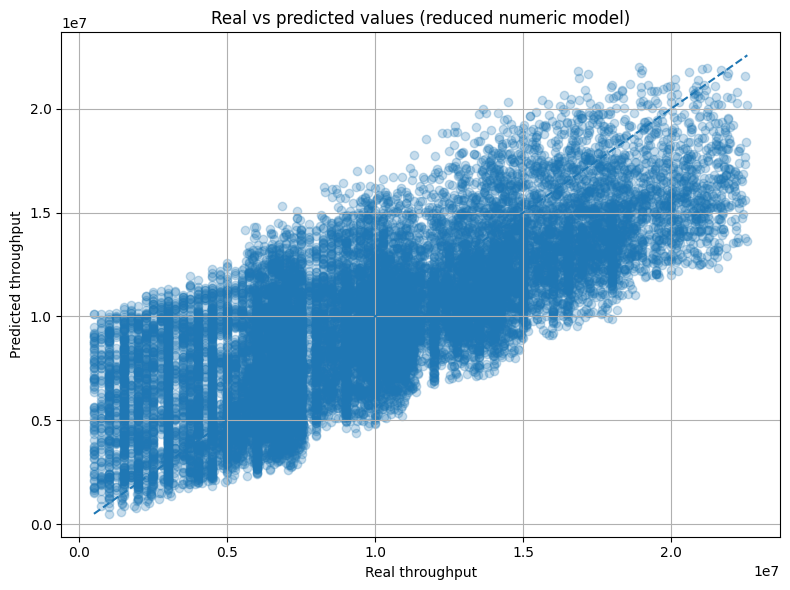

In [21]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_reduced, alpha=0.25)
val_min = min(y_test.min(), y_pred_test_reduced.min())
val_max = max(y_test.max(), y_pred_test_reduced.max())
plt.plot([val_min, val_max], [val_min, val_max], linestyle="--")
plt.xlabel("Real throughput")
plt.ylabel("Predicted throughput")
plt.title("Real vs predicted values (reduced numeric model)")
plt.tight_layout()
plt.show()

The scatter plot confirms that the model captures a substantial part of the signal, but not perfectly.  
The dispersion around the diagonal indicates that a simple linear relationship is not sufficient to explain all throughput variations.

## 19. Residual analysis

Residual analysis is useful because it tells us whether the model misses systematic structure.

If the residuals show visible patterns, asymmetry, or changing variance, then the linear specification is only a partial approximation of the data-generating process.

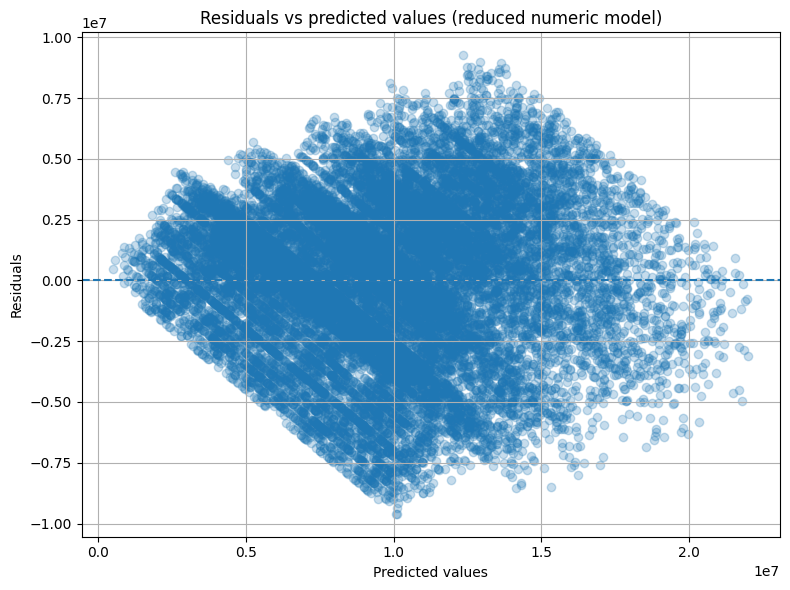

In [22]:
residuals = y_test - y_pred_test_reduced

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_test_reduced, residuals, alpha=0.25)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title("Residuals vs predicted values (reduced numeric model)")
plt.tight_layout()
plt.show()

### Comment

The residual cloud is not purely random.  
This suggests that the linear model is useful as a **baseline**, but does not fully capture the complexity of the Wi‑Fi system.  
Possible explanations include:

- nonlinear effects,
- interactions between variables,
- threshold effects linked to discrete protocol parameters,
- and remaining heterogeneity not explained by a purely linear specification.

## 20. Final conclusion

This notebook gives four main results.

1. The dataset is clean in the sense that there are no missing values and no duplicates.  
   But it still needs some modelling choices before fitting a regression.

2. The full model has clear multicollinearity issues.  
   This is especially true for `area`, `size_x`, `size_y`, and the RSSI variables.

3. Some variables should not really be seen as continuous.  
   This is the case for `cw`, `channel_width`, and `packet_size`, which only take a few possible values.

4. The full numeric model gives the best predictive results, but the reduced one-hot model stays close while being easier to interpret.
